In [1]:
from torchvision import datasets, transforms
import torch

# Convert image to tensor
transform = transforms.ToTensor()

# Load both training and test parts
train_data = datasets.MNIST(
    root='data',
    train=True,
    transform=transform,
    download=True
    )
test_data  = datasets.MNIST(
    root='data',
    train=False,
    transform=transform,
    download=True
    )

all_data = torch.cat((train_data.data, test_data.data), dim=0)
all_targets = torch.cat((train_data.targets, test_data.targets), dim=0)

100.0%
100.0%
100.0%
100.0%


In [2]:
from sklearn.model_selection import train_test_split

# add a channel dimension and normalize to [0, 1]
all_data = all_data.unsqueeze(1).float() / 255.0

train_data, temp_data, train_targets, temp_targets = train_test_split(
    all_data,
    all_targets,
    train_size=0.60,
    stratify=all_targets,
    random_state=42
)


val_data, test_data, val_targets, test_targets = train_test_split(
    temp_data,
    temp_targets,
    train_size=0.50,
    stratify=temp_targets,
    random_state=42
)


In [3]:
from torch.utils.data import random_split, DataLoader, TensorDataset

train_dataset = TensorDataset(train_data, train_targets)
val_dataset = TensorDataset(val_data, val_targets)
test_dataset = TensorDataset(test_data, test_targets)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [4]:
import torch.nn as nn

# Define the FeedForward Neural Network
class FeedForwardNN(nn.Module):
    def __init__ (self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28*28, 128)
        self.activation = nn.ReLU()
        self.hidden2 = nn.Linear(128, 256)
        self.output = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.output(x)
        return x

In [5]:
# Applying He initialization to the model weights
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

model = FeedForwardNN()
model.apply(initialize_weights)

FeedForwardNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (activation): ReLU()
  (hidden2): Linear(in_features=128, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=10, bias=True)
)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

import torch.optim as optim
# Define Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [7]:
epochs= 100

train_loss = []
val_loss = []
train_acc = []
val_acc = []

patience = 3
patience_counter = 0
improvement_threshold = 1e-3
best_val_loss = float('inf')
model_path = 'model_checkpoint.pth'

for epoch in range(epochs):
    model.train()

    train_loss_epoch = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(inputs)

        # Calculate Loss
        loss = loss_fn(outputs, labels)

        # Comute Gradients
        loss.backward()
        optimizer.step()

        train_loss_epoch += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Calculate average training loss and accuracy for the epoch
    avg_train_loss = train_loss_epoch / len(train_loader)
    avg_train_acc = 100 * correct_train / total_train

    train_loss.append(avg_train_loss)
    train_acc.append(avg_train_acc)

    # Validation 
    model.eval()

    val_loss_epoch = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            val_loss_epoch += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss_epoch / len(val_loader)
    avg_val_acc = 100 * correct_val / total_val

    val_loss.append(avg_val_loss)
    val_acc.append(avg_val_acc)

    # Early Stopping and saving Checkpoints
    improvement = best_val_loss - avg_val_loss
    if improvement > improvement_threshold:
        best_val_loss = avg_val_loss
        patience_counter = 0

        torch.save(model.state_dict(), model_path)
    else:
        patience_counter += 1
    if patience_counter >= patience:
      print(f"Early stopping after {epoch + 1} epochs")
      break

Early stopping after 49 epochs


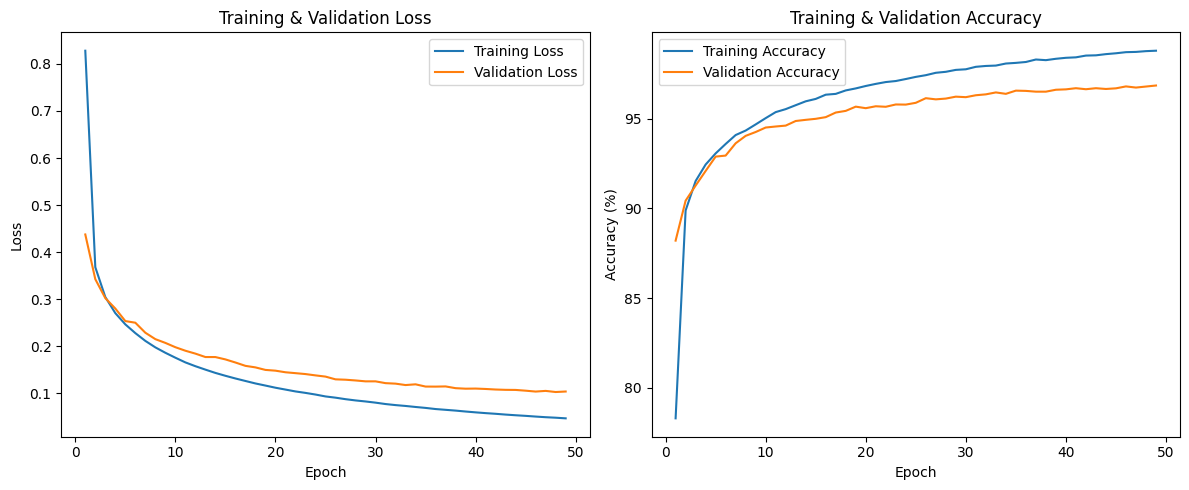

In [8]:
model.load_state_dict(torch.load(model_path))
epochs_range = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## Convergence Analysis :

### **Loss**

* The **training loss** (blue) decreased steadily throughout the training process, indicating that the model was successfully learning from the training data.
* The **validation loss** (red) also decreased overall but exhibited small fluctuations due to the stochastic nature of **mini-batch gradient descent**.

### **Accuracy**

* The **training accuracy** showed a consistent upward trend across epochs.
* The **validation accuracy** improved initially and then **plateaued**.

### **Convergence and Early Stopping**

* The model trained for a total of **49** epochs.
* **Early stopping** was triggered when the **validation loss** failed to improve by more than **0.001** for **3 consecutive epochs** (patience = 3).
* The **best model** was saved from **epoch 49**, representing the point of **optimal convergence** before overfitting began.
